In [1]:
import jax.numpy as jnp
import numpy as np
import jax
from jax import grad, jit, random
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def generate_single_circle(normal, pts, m, phase=0.0):
    
    # Normalize just in case
    n = normal / jnp.linalg.norm(normal)
    v1 = jnp.array([1., 0., 0.]) if abs(n[0]) < 0.9 else jnp.array([0., 1., 0.])
    v1 = v1 - n * jnp.dot(n, v1)
    v1 /= jnp.linalg.norm(v1)
    v2 = jnp.cross(n, v1)

    # Apply phase shift directly to phi
    phi = jnp.linspace(0, 2*jnp.pi, pts, endpoint=False) + phase
    phi = phi % (2*jnp.pi)

    # Geometry on the sphere
    X = jnp.outer(jnp.cos(phi), v1) + jnp.outer(jnp.sin(phi), v2)

    # Circular harmonic ground truth
    y = jnp.sin(m * phi)

    return X, y

def generate_normals(K):

    # Fibonacci sphere sampling to get normals
    idx = jnp.arange(0, K, dtype=float) + 0.5
    phi = jnp.arccos(1 - 2 * idx / K)
    theta = jnp.pi * (1 + 5**0.5) * idx
    
    x = jnp.sin(phi) * jnp.cos(theta)
    y = jnp.sin(phi) * jnp.sin(theta)
    z = jnp.cos(phi)
    
    return jnp.vstack([x, y, z]).T

def generate_multi_great_circle_tasks(
    K_tasks=2,
    pts_per_circle=512,
    m=4,
    phase=0.0,
    random_phase=False
):
    normals = generate_normals(K_tasks)

    X_list, y_list, slices = [], [], []
    start = 0

    for j, n in enumerate(normals):
        if random_phase:
            phase_j = jnp.random.rand() * 2*jnp.pi
        else:
            phase_j = phase

        X, _ = generate_single_circle(n, pts_per_circle, m, phase=phase_j)
        y = np.zeros((X.shape[0],K_tasks))
        y[:,j]=1

        X_list.append(X)
        y_list.append(y)
        slices.append(slice(start, start + pts_per_circle))
        start += pts_per_circle

    return (
        jnp.vstack(X_list),
        jnp.concatenate(y_list),
        slices,
        normals,
    )

In [3]:
def run(
        K, # Number of tasks
        m, # Circular harmonic degree
        hidden_size,
        log_step,
        steps,
        pts_per_circle = 300,
        hidden_layer_num = 1,
        ):

    X, y, slices, normals = generate_multi_great_circle_tasks(
        K_tasks=K, pts_per_circle=pts_per_circle, m=m
    )

    X = jnp.array(X)
    Y = jnp.array(y)

    # set split fraction
    train_frac = 0.8
    n = X.shape[0]
    n_train = int(train_frac * n)

    # shuffle (with PRNG)
    key = jax.random.PRNGKey(42)
    perm = jax.random.permutation(key, n)

    X = X[perm]
    Y = Y[perm]

    # slice
    X_train, X_test = X[:n_train], X[n_train:]
    Y_train, Y_test = Y[:n_train], Y[n_train:]

    # define architecture
    layer_sizes = [3] + [hidden_size]*hidden_layer_num + [K]  # e.g., [3,512,512,...,K]

    # init all params
    key = random.PRNGKey(0)
    keys = random.split(key, len(layer_sizes))

    def init_mlp_params(sizes, keys):
        params = []
        for k, (in_dim, out_dim) in zip(keys, zip(sizes[:-1], sizes[1:])):
            W = random.normal(k, (in_dim, out_dim)) * jnp.sqrt(2/in_dim)
            b = jnp.zeros((out_dim,))
            params.append((W, b))
        return params

    params = init_mlp_params(layer_sizes, keys)

    # forward pass through L layers
    def forward(params, x):
        for i, (W, b) in enumerate(params[:-1]):
            x = jax.nn.relu(x @ W + b)
        W, b = params[-1]
        logits = x @ W + b
        return logits

    def loss_fn(params, x, y):
        logits = forward(params, x)
        loss = jnp.mean(-jnp.sum(y * jax.nn.log_softmax(logits), axis=1))
        return loss

    @jit
    def update(params, x, y, lr=1e-3):
        grads = grad(loss_fn)(params, x, y)
        return [(W - lr * dW, b - lr * db)
                for (W, b), (dW, db) in zip(params, grads)]


    results={'time':[], 'loss':[], 'acc':[]}

    # train for 200 steps
    for i in range(steps):
        params = update(params, X_train, Y_train)

        if i%log_step==0:
            results['time'].append(i)
            results['loss'].append(loss_fn(params, X_test, Y_test))
            results['acc'].append(jnp.mean(jnp.argmax(forward(params, X_test), axis=1) == jnp.argmax(Y_test, axis=1)))

    return results

We have 3 hyperparameters we can tune: K, hidden_size and points_per_circle. 

Classification accuracy vs training time for different K, fixed hidden size and pts_per_circle

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [05:36<00:00, 25.85s/it]


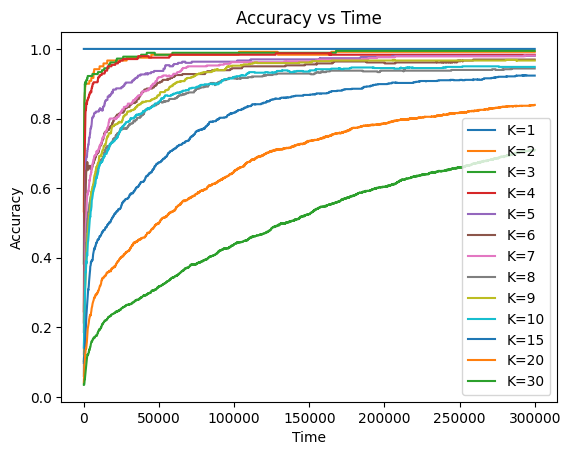

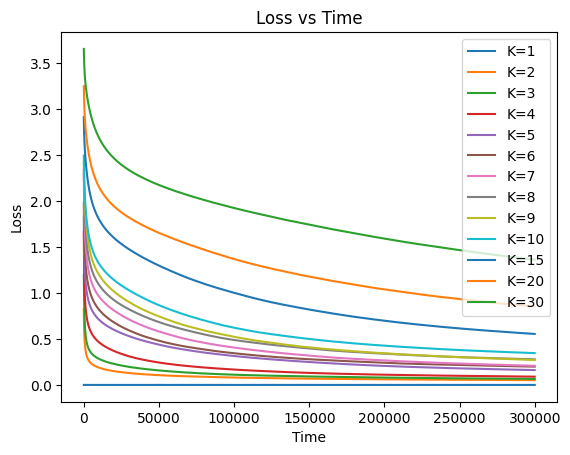

In [6]:
Ks = [1,2,3,4,5,6,7,8,9,10,15,20,30]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for K in tqdm(Ks):
    results = run(K=K, m=3, hidden_size=512, log_step=100, steps=300001, pts_per_circle=300)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"K={K}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"K={K}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

Let's take a look at K=30 and see if we can find a combination of the other two hyperparameters that fixes the convergence, or at least speeds it up

100%|██████████| 7/7 [15:40<00:00, 134.30s/it]


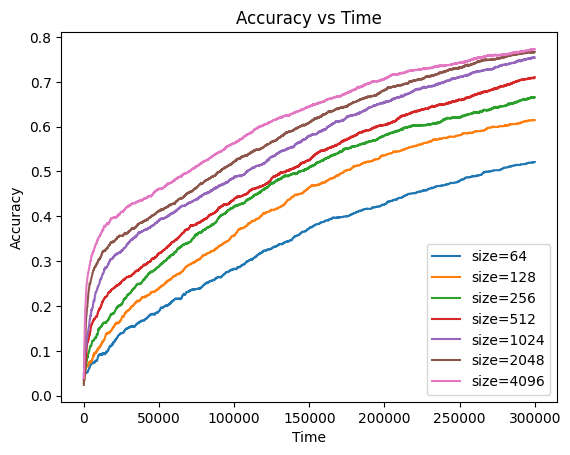

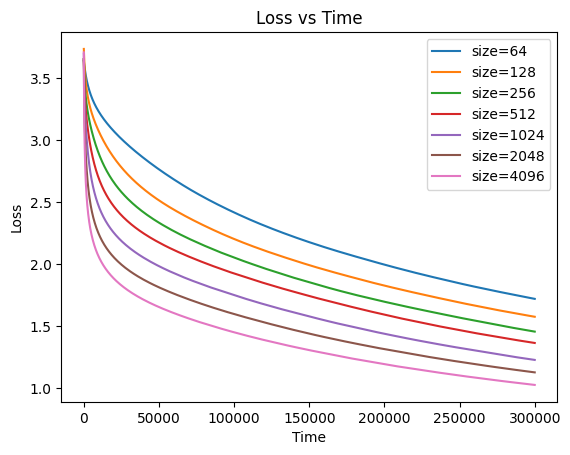

In [8]:
hidden_sizes = [64,128,256,512,1024,2048,4096]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for hidden_size in tqdm(hidden_sizes):
    results = run(K=30, m=3, hidden_size=hidden_size, log_step=100, steps=300001, pts_per_circle=300)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"size={hidden_size}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"size={hidden_size}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [24:53<00:00, 298.63s/it]


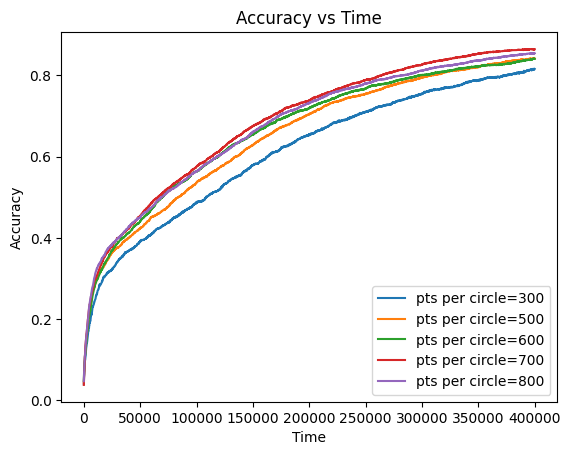

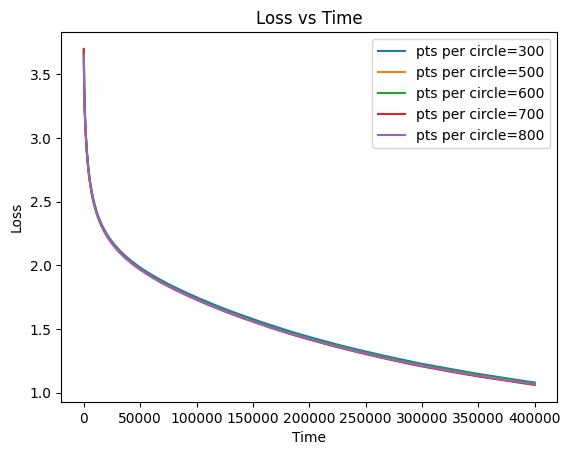

In [11]:
pts_per_circles = [300,500,600,700,800]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for pts_per_circle in tqdm(pts_per_circles):
    results = run(K=30, m=3, hidden_size=1024, log_step=100, steps=400001, pts_per_circle=pts_per_circle)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"pts per circle={pts_per_circle}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"pts per circle={pts_per_circle}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

In [ ]:
hidden_sizes = [256,512,1024,2048,4096]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for hidden_size in tqdm(hidden_sizes):
    results = run(K=30, m=3, hidden_size=hidden_size, log_step=100, steps=300001, pts_per_circle=512, hidden_layer_num=3)
    
    # plot accuracy in the first figure
    ax1.plot(results['time'], results['acc'], label=f"size={hidden_size}")
    
    # plot loss in the second figure
    ax2.plot(results['time'], results['loss'], label=f"size={hidden_size}")

ax1.legend()
ax2.legend()

ax1.set_title("Accuracy vs Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Accuracy")

ax2.set_title("Loss vs Time")
ax2.set_xlabel("Time")
ax2.set_ylabel("Loss")

plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

 60%|██████    | 3/5 [35:23<28:00, 840.18s/it]